In [1]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)

Features shape: (150, 4)
Target shape: (150,)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (120, 4)
Testing data: (30, 4)


# (a) Scale the features using StandardScaler

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First 5 scaled training samples:")
print(X_train_scaled[:5])

First 5 scaled training samples:
[[-1.72156775 -0.33210111 -1.34572231 -1.32327558]
 [-1.12449223 -1.22765467  0.41450518  0.6517626 ]
 [ 1.14439475 -0.5559895   0.58484978  0.25675496]
 [-1.12449223  0.11567567 -1.28894078 -1.45494479]
 [-0.40800161 -1.22765467  0.13059752  0.12508575]]


# (b) Classify the test set and print correct/wrong predictions

In [4]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("Actual values:   ", y_test)
print("Predicted values:", y_pred)

Actual values:    [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]
Predicted values: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]


In [5]:
correct = 0
wrong = 0

for actual, predicted in zip(y_test, y_pred):
    if actual == predicted:
        correct += 1
    else:
        wrong += 1

print("Correct predictions:", correct)
print("Wrong predictions:", wrong)

Correct predictions: 28
Wrong predictions: 2


# (c) Vary k from 1 to 15

In [6]:
from sklearn.metrics import accuracy_score

k_values = range(1, 16)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

print("k values:")
print(list(k_values))

print("\nAccuracies:")
print(accuracies)

k values:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

Accuracies:
[0.9666666666666667, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 0.9333333333333333, 0.9666666666666667, 0.9333333333333333, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667, 0.9666666666666667]


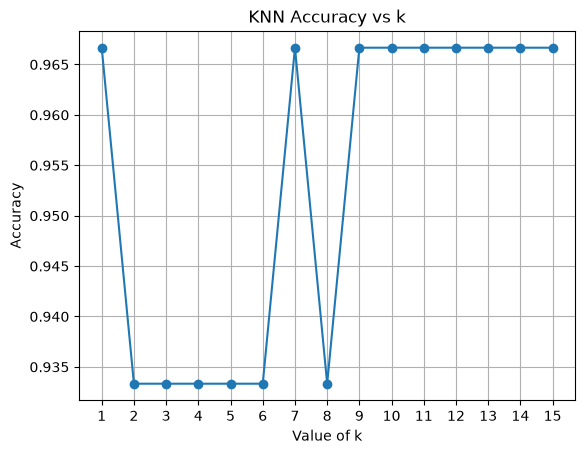

In [7]:
import matplotlib.pyplot as plt

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("Value of k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k")

plt.xticks(k_values)
plt.grid()

plt.show()

In [8]:
best_index = accuracies.index(max(accuracies))

best_k = list(k_values)[best_index]
best_accuracy = accuracies[best_index]

print("Best value of k:", best_k)
print("Best accuracy:", best_accuracy)

Best value of k: 1
Best accuracy: 0.9666666666666667
